# Predicción de salario anual utilizando Random Forest
Estudiantes: Benjamín Espinoza Acevedo (benjaespinozaacevedo-ctrl) - Thomas Gómez Venegas (ThomasTg7)

# Librerias


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

# Carga de datos
Utilizando el dataset Job Salary Prediction Dataset, se implementara una forma alternativa para tomar una meustra de 10.000 filas aleatorias con el fin de entrenar y probar mientras se desarrolla, ya que entrenar un modelo con una gran cantidad de datos, en este caso una cantidad de 250.000 filas se necesita tiempo para que los codigos corran, ralentizando la operacion. 

In [2]:
RUTA_CSV = "job_salary_prediction_dataset.csv"
data_completa = pd.read_csv(RUTA_CSV)
USAR_MUESTRA = False   #interruptor donde al estar en TRUE, utilizamos la muestra
N_MUESTRA    = 10000   
SEMILLA = 777                
np.random.seed(SEMILLA)

if USAR_MUESTRA: #condicional para verificar si se ua la muestra o el dataset completo
    data = data_completa.sample(n=N_MUESTRA, random_state=SEMILLA).reset_index(drop=True)
    print("Usando la MUESTRA")
else:
    data = data_completa.copy()
    print("Usando el dataset COMPLETO")

data.head()

Usando el dataset COMPLETO


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


# Analisis de los datos
Ahora analizaremos los datos, comenzando por mirar la forma de los datos, sus tipos, si existen valores faltantes, etc.

In [3]:
print("Filas y columnas:", data.shape) #ver las filas y columnas del dataset con tipo de datos
data.info()

Filas y columnas: (250000, 10)
<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 19.1 MB


In [4]:
data.describe() #resumen estadistico de variables numericas

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [5]:
data.isnull().sum() #verificar nulos por columna

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [6]:
data.duplicated().sum() #verfiicar filas duplicadas

np.int64(0)

Luego de correr las diferentes lineas podemos observar que tenemos 10 variables, donde 4 son numericas y 6 categoricas. Dentro de las numericas tenemos la experiencia (experience_years), la cantidad de habilidades (skills_count), los certificados (certifications) y por ultimo la variable objetivo salario (salary). En cuanto a las variables numericas podemos entender diferentes datos interesantes:

Experiencia: Sabiendo que esta medida en años, donde tenemos que el rango es de 0 a 20 años, teniendo un promedio de 10 años de experiencia en los trabajadores del dataset.

Cantidad de habilidades: Tenemos que la cantidad de las habilidades van desde 1 a 19 habilidades, donde el promedio es de aproximadamente 10. 

Certificados: En cuanto a la cantidad de certificados podemos ver que el minimo es 0 y el maximo 5, donde el promedio es de 2,49.

Salarios: En cuanto a los salarios podemos ver que el minimo es de 31.867 USD al año, en cuanto al maximo tenemos 333.046 USD al año, el promedio es de 145.718 USD al año. 

In [7]:
print("Trabajos del dataset:", data["job_title"].value_counts()) #mostramos las categorias de cada variable categorica y cuanto aparecen
print("Niveles de educacion:", data["education_level"].value_counts())
print("Industrias:", data["industry"].value_counts())
print("Tamaños de empresa:", data["company_size"].value_counts())
print("Paises del dataset:", data["location"].value_counts())
print("Indicador de trabajo remoto", data["remote_work"].value_counts())

Trabajos del dataset: job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64
Niveles de educacion: education_level
Master         50352
High School    50065
Bachelor       49950
PhD            49857
Diploma        49776
Name: count, dtype: int64
Industrias: industry
Finance          25393
Consulting       25258
Media            25034
Manufacturing    25024
Technology       24903
Government       24901
Healthcare       24898
Education        24889
Telecom          24859
Retail           24841
Name: count, dtype: int64
Tamaños de empresa: company_size
Large         50254
Small         50235
Med

Como podemos ver en la salida anterior, podemos entender nuestras variables categoricas.

Trabajos: En esta variables podemos observar que tenemos 12 trabajos diferentes, donde son bastante uniformes en cuanto a la cantidad y todos muy relacionados con la tecnologia, negocios e ingeneria.

Niveles de educacion: En cuanto a la educacion podemos ver que tenemos 5, las cuales son Master, High School, Bachelor, PhD y Diploma.

Industrias: Los sectores de industrias identificados son de finanzas, consultoria y media. 

Tamaños de empresa: Podemos ver que hay 5 distintos tamaños de empresa, donde tenemos grandes, pequeñas, medianas, gran empresa (multinacional) y por ultimo Startup.

Paises: Los paises de los trabajadores son 10, aun uno es catalogado como remoto, intuimos que es porque el trabajador trabaja 100% remoto

Indicador de trabajo remoto: Tenemos 3 estados de indicador, donde tenemos el hibrido, si es remoto o no.


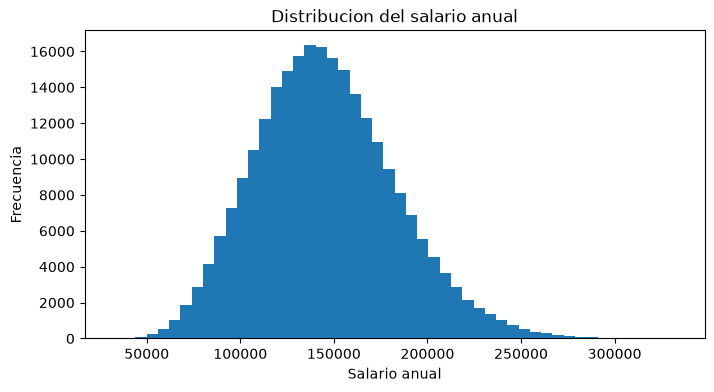

In [8]:
plt.figure(figsize=(8, 4)) #histograma para visualizar la distribucion del salario en el dataset
plt.hist(data["salary"], bins=50)
plt.xlabel("Salario anual")
plt.ylabel("Frecuencia")
plt.title("Distribucion del salario anual")
plt.show()

Podemos ver que la distribucion del salario parece una normal, aunque un poco sesgada a la derecha. Esto nos da como ventaja que el random forest que aplicaremos, ya que tenemos pocos valores atipicos, evitando que se distorsionen fuertemente los promedios. Ademas al tener una distribucion parecida a la normal, le da mucha mas informacion para aprender los patrones en los casos mas tipicos, siendo mas preciso cuando los salarios se acercan a la media.

# Seleccion de variables
Ahora analizaremos una seleccion de variables para entender y utilizar las variables que realmente afectan al salario y descartar aquellas que no aportar a la prediccion, ya que un modelo con menos variables y solo las mas relevantes, puede ser mas interpretable y mas facil de usar

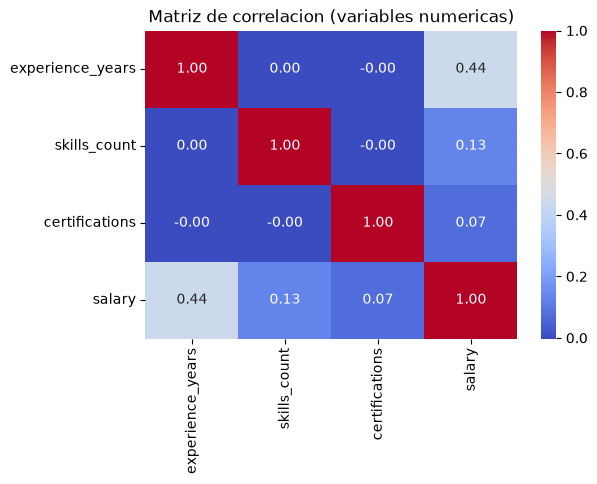

In [9]:
numericas = ["experience_years", "skills_count", "certifications", "salary"] #seleccionamos las variables que sabemos q son numericas
correlation_matrix = data[numericas].corr() #correlacion de pearson entre las variables

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlacion (variables numericas)")
plt.show()

Para las variables numericas, podemos simplemente generar la matriz de correlacion que vemos en la salida anterior y a partir de eso, seleccionar variables. Como podemos notar la variable con mayor correlacion es la experiencia con el salario, mientras que la cantidad de habilidades y certificados tiene una relacion bastante baja, es por esto que no las seleccionaremos para el modelo predictor, quedandonos solo con la experiencia en cuanto a las variables numericas.

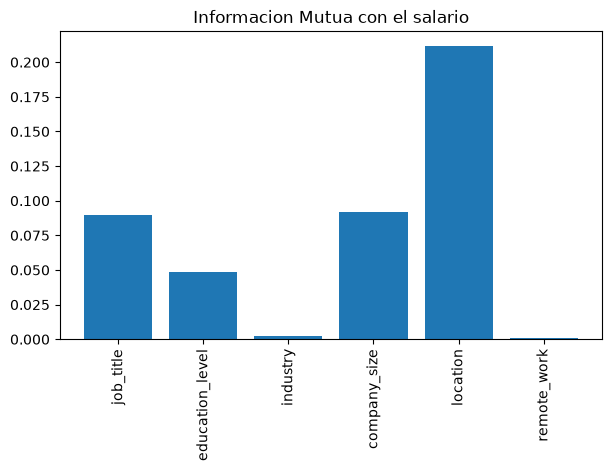

In [10]:
CAT_COLS = ["job_title", "education_level", "industry", "company_size", "location", "remote_work"] #seleccionamos las variables categoricas

data_encoded = data.copy()
for col in CAT_COLS: #iteramos sobre sobre nuestras variables categoricas
    data_encoded[col] = LabelEncoder().fit_transform(data_encoded[col]) #convertimos cada sub variable a un numero de las variables categoricas
mi_scores = mutual_info_regression(data_encoded[CAT_COLS], data["salary"], random_state=SEMILLA) #cada variable recibe un score segun cuanto aportan al efecto del salario

plt.figure(figsize=(7, 4))
plt.bar(CAT_COLS, mi_scores)
plt.title("Informacion Mutua con el salario")
plt.xticks(rotation=90)
plt.show()

Para analizar las variables categoricas, sabemos que los modelos no pueden analizar texto, entonces primero debemos asignar un numero a cada categoria dentro de las variables categoricas, luego el score mide cuanta incertidumbre del salario elimina al conocer esa categoria, si el score es alto la variable dice mucho sobre el salario sino no aporta mucho.

Ahora podemos ver en el grafico que las variables que mas importantes categoricas son el pais (location), el titulo que tengan (job tittle), el tamaño de la empresa (company_size) y el nivel de educacion (education_level), en cuanto a las otras dos variables, vemos que tienen un score extremadamente bajo, entonces no seran seleccionadas para entrenar y probar el modelo.

In [11]:
VAR_NUM = ["experience_years"] #nos quedamos unicamente con la variable numerica experiencia
VAR_CAT = ["job_title", "location", "company_size", "education_level"] #variables categoricas seleccionadas
FEATURES = VAR_NUM + VAR_CAT #lista completa de variables predictoras
print("Predictoras usadas:", FEATURES)
print("Descartadas:", ["skills_count", "certifications", "industry", "remote_work"])

Predictoras usadas: ['experience_years', 'job_title', 'location', 'company_size', 'education_level']
Descartadas: ['skills_count', 'certifications', 'industry', 'remote_work']


# Preprocesamiento
Ahora debemos separar la variable objetivo (salary) de las predictoras y transformamos las variables categoricas a numeros, descubrimos one-hot con pd.get_dummies y lo utilizamos porque convierte cada categoria en su propia columna 0/1 sin un orden numerico de las variables , permitiendo que el Random Forest trate cada categoría de forma independiente

In [12]:
y = data["salary"] #el salario es nuestra variable objetivo
X = data[FEATURES] #variables  independientes predictoras
X = pd.get_dummies(X, columns=VAR_CAT, drop_first=False) #creamos dummys 0 o 1 por categoria, sin imponer un orden numerico
print("Forma de X tras one-hot:", X.shape)
X.head()

Forma de X tras one-hot: (250000, 33)


,experience_years,job_title_AI Engineer,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,job_title_DevOps Engineer,job_title_Frontend Developer,...,company_size_Enterprise,company_size_Large,company_size_Medium,company_size_Small,company_size_Startup,education_level_Bachelor,education_level_Diploma,education_level_High School,education_level_Master,education_level_PhD
0,10,True,False,False,False,False,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False
1,5,False,False,False,False,False,True,False,False,False,...,False,False,False,True,False,True,False,False,False,False
2,18,False,False,False,False,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,True
3,19,False,False,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
4,15,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,False


# Division en entrenamiento y prueba
Comenzamos con la division de entrenamiento y prueba, donde nos quedamos con la proporcion tipica de un 20% de los datos para probar y y el 80% para el entrenamiento, fijamos la semilla para que la particion sea la misma siempre.

In [13]:
X_train, X_test, y_train, y_test = train_test_split( 
    X, y, test_size=0.2, random_state=SEMILLA) #dividimos el conjunto de datos en 20% para test y el 80% para el train
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (200000, 33)  Test: (50000, 33)


# Random Forest

Luego de fijar la division de entrenamiento y prueba, probaremos cuantos arboles usar mirando el error de validacion cruzada, lo dejamos en RMSE para entenderlo mejor, cuando la curva deje de bajar nos indicara que agregar mas arboles no nos ayuda y solo afecta negativamente a la eficiencia computacional.

En cuanto a la profundidad de los arboles, debemos indicarle al modelo cuanto crecer, para eso tambien probaremos diferentes valores, donde analizaremos el valor de r2 tanto en el train como en la validacion cruzada

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEMILLA) #particion de la validacion cruzada con k=5

df = [] #lista vacia para almacenar los valores
for n in [10, 50, 100, 200, 300]:        #probamos distintas cantidades de arboles
    modelo = RandomForestRegressor(n_estimators=n, random_state=SEMILLA, n_jobs=-1) #validamos en el train
    cv = cross_validate(modelo, X_train, y_train, scoring=["neg_mean_squared_error"], cv=kf, n_jobs=-1) #se nos entrega el mse en negativo, entonces lo invertimos y sacamos raiz para obtener rmse medio
    rmse_cv = np.sqrt(-cv["test_neg_mean_squared_error"].mean())
    df.append({"n": n, "rmse_cv": rmse_cv})    #guardamos el resultado de cada n
df = pd.json_normalize(df)                      #pasamos la lista de dicts a tabla

plt.plot(df["n"], df["rmse_cv"], marker="o")    #curva de error segun cantidad de arboles
plt.xlabel("n_estimators")
plt.ylabel("rmse validacion (USD)")
plt.title("Error de validacion cruzada segun cantidad de arboles")
plt.show()
df 

Como vemos en el grafico, baja abruptamente en el segundo valor, es decir con n=50, para luego mantenerse bastante estable dentro del rango de RMSE = 10600, ademas que con la tabla podemos ver mas a detalle, que en valor n=200 es el mejor valor a elegir, principalmente por la eficiencia computacional y que los valores arrojados con un numero mayor son practicamente identicos y no vale la pena generar mas arboles por una mejora tan poco significativa.

In [ ]:
df = []
for prof in [5, 10, 15, 20, 25, None]: #probamos distintas profundidades
    modelo = RandomForestRegressor(n_estimators=200, max_depth=prof, random_state=SEMILLA, n_jobs=-1)
    modelo.fit(X_train, y_train) #entrenamos para medir el r2 de train
    cv = cross_validate(modelo, X_train, y_train, scoring=["r2"], cv=kf, n_jobs=-1) #r2 de validacion cruzada sin tocar el test
    df.append({"max_depth": prof if prof else "None",
               "train_r2": r2_score(y_train, modelo.predict(X_train)),  #ajustamos en train
               "val_r2": cv["test_r2"].mean()})                          #ajustamos en validacion
df = pd.json_normalize(df)
df   

,max_depth,train_r2,val_r2
0,5,0.637680,0.628018
1,10,0.877715,0.843902
2,15,0.962935,0.910694
3,20,0.984108,0.920498
4,25,0.987439,0.920518
5,None,0.987652,0.920249


Ahora vemos la profundidad, para manejar tambien el overfitting, la idea fue probar con diferentes valores para entender el mejor, en cuanto a eficiencia computacional y resultados, como podemos ver con max_depth= 20 se alcanza un punto optimo, ya que luego las mejoras no son significativas cuando el numero es mayor. 

Con esto, hemos elegido nuestros parametros, donde tendremos un modelo donde usamos 200 arboles y con una profundidad de 20

In [ ]:
modelo = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=SEMILLA, n_jobs=-1) #modelo final con parametros elegidos
modelo.fit(X_train, y_train) #entrenamos el modelo con el train

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",777
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"ma

# Validacion cruzada k-fold (norma L2 / MSE)
Mediremos la generalizacion del modelo con k-fold, partiendo el train en 5 conjuntos, donde 4 se usaran para entrenar, 1 para rotar y usarlo de test. El valor de k=5 se eligio principalmente porque leimos que era un valor estandar, ademas de ser utilizado tanto en clases como en los notebooks del repositorio del curso.

Usaremos el error cuadratico medio como funcion de costo, minimizando con la norma L2

In [ ]:
cv = cross_validate(
    modelo, X_train, y_train,
    scoring=["neg_mean_squared_error"], #funcion de costo, en este caso error cuadrativo norma l2
    cv=kf, n_jobs=-1
)
mse_folds = -cv["test_neg_mean_squared_error"] #transformamos el mse a positivo en cada fold
print("MSE por fold:", mse_folds.round(0))
print("MSE medio:", round(mse_folds.mean(), 0))
print("RMSE medio:", round(np.sqrt(mse_folds.mean()), 0)) #sacamos raiz para leerlo el usd

MSE por fold: [1.05169334e+08 1.13996708e+08 1.15135632e+08 1.11060547e+08
 1.11142193e+08]
MSE medio   : 111300883.0
RMSE medio  : 10550.0


In [ ]:
y_pred = modelo.predict(X_test) #prediccion sobre el test
mse  = mean_squared_error(y_test, y_pred) #error cuadrativo medio
rmse = np.sqrt(mse) #sacamos raiz del mse para ver en usd
r2   = r2_score(y_test, y_pred) #proporcion de varianza explicada
r = np.corrcoef(y_test, y_pred)[0, 1] #correlacion de pearson entre lo real y lo predicho
print("MSE:", round(mse, 0))
print("RMSE:", round(rmse, 0))
print("R2:", round(r2, 4))
print("r:", round(r, 4))

MSE : 110753296.0
RMSE: 10524.0
R2  : 0.9221
r   : 0.9606


Viendo las salidas podemos ver que el modelo sobre el conjunto que no vio predice con un error medio de 10.550 USD, sabiendo antes que el salario promedio es de 145.480, teniendo un R2 de 0.9221, nos indica que el modelo explica aproximadamente el 92% de la variacion de los salarios, usando las cinco variables que seleccionamos, podriamos decir que el modelo generaliza bien y no sufre de overfitting

# Predicho vs Real
Ahora crearemos un grafico donde cada punto es un trabajador del test: eje X = salario real, eje Y = salario predicho, mientras mas
pegados esten los puntos a la diagonal roja, mejor predice el modelo

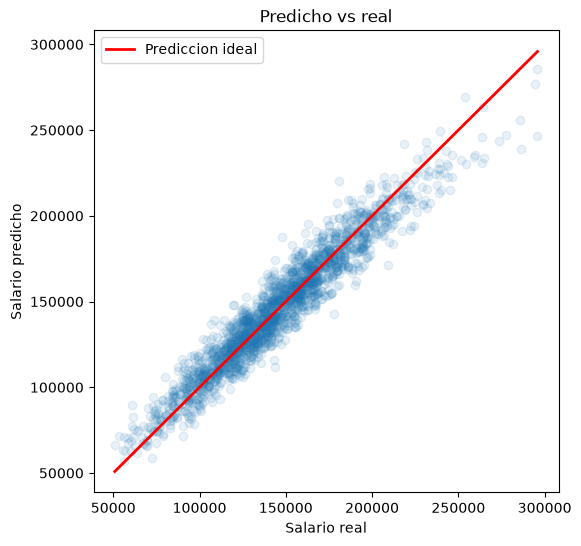

In [ ]:
plt.figure(figsize=(6, 6)) #grafico para visualizar los datos predicos vs los reales
plt.scatter(y_test, y_pred, alpha=0.1)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, color="red", linewidth=2, label="Prediccion ideal") #linea que nos indica la prediccion perfecta
plt.xlabel("Salario real")
plt.ylabel("Salario predicho")
plt.title("Predicho vs real")
plt.legend()
plt.show()

Podemos notar que los puntos se pegan bien a la diagonal, esto nos confirma que el modelo predice bien y en todo el rango de salarios, los puntos se concentran mucho mas entre 100.000 y 200.000 USD. Tambien podemos ver que en el extremo superior derecho, hay menos datos y mas dispersos, es decir que el modelo predice peor ya que son valores atipicos y se guia mas por el promedio, pero es esperable y normal con valores demasiado atipicos.

# Importancia de las variables
Random Forest nos entrega la importancia de cada columna, como el one-hot crea varias columnas por variable, las sumamos por grupo para obtener la importancia de la variable original. Aca esperamos que el pais, es decir la variable location sea la mas importante, ya que el nivel socioeconomico de cada pais influye directamente en cuanto se paga por un mismo trabajo.

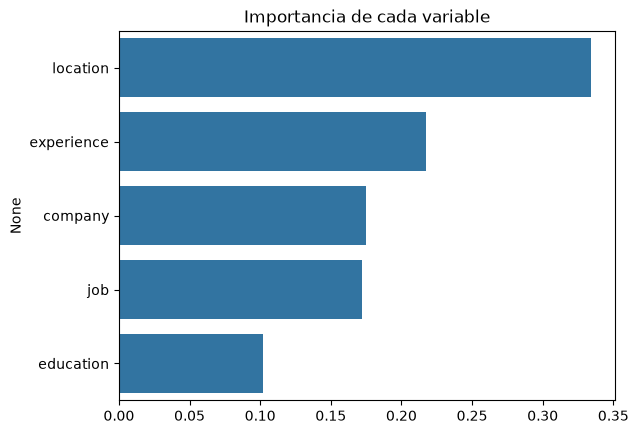

location      0.334396
experience    0.217180
company       0.174641
job           0.172120
education     0.101663
dtype: float64

In [ ]:
importancias = pd.Series(modelo.feature_importances_, index=X.columns) #importancia de cada columna
categorias = ["location", "experience", "company", "job", "education"] #nombres de las variables

def categorizar(columna): #devuelve a que variable original pertenece cada columna del one-hot
    for categoria in categorias:
        if categoria in columna: #busca el nombre base dentro del nombre de la columna
            return categoria
importancias_categorias = (importancias #agrupamos por variable origina y sumamos las importancias de sus columnas
       .groupby([categorizar(c) for c in X.columns])
       .sum()
       .sort_values(ascending=False)) 

sns.barplot(x=importancias_categorias.values, y=importancias_categorias.index)
plt.title("Importancia de cada variable")
plt.show()
importancias_categorias

Como habiamos intuido, la variable mas importante es el pais, con mas de un 30% de importancia, como segunda vemos que es la experiencia, siendo mayor al 20%, por ultimo tenemos el tamaño de la compañia, el trabajo y la educacion. Sorprende que la educacion sea la variable menos importante, siendo que esta podria ser percibida como una importante variable a considerar cuando se piensa en efectos sobre nuestro salario futuro y vemos que mucho mas importante la cantidad de años que llevaras en tu trabajo

# Linealidad del efecto de la experiencia sobre el salario
Ahora analizaremos como se comporta el efecto de la experiencia sobre el salario de los trabajadores, para esto debemos aislar el efecto de la experiencia sobre el salario que predice el modelo, la idea es tomar a todos los trabajadores del test y les cambiamos solo la experiencia, desde 0 hasta 20 años, dejando todo lo demas igual. Para cada valor de experiencia calculamos el salario promedio que predice el modelo. Asi vemos cuanto sube el salario solo por tener mas experiencia, sin que influyan las otras variables. Despues graficamos esos promedios y agregamos una recta que une el inicio con el final.

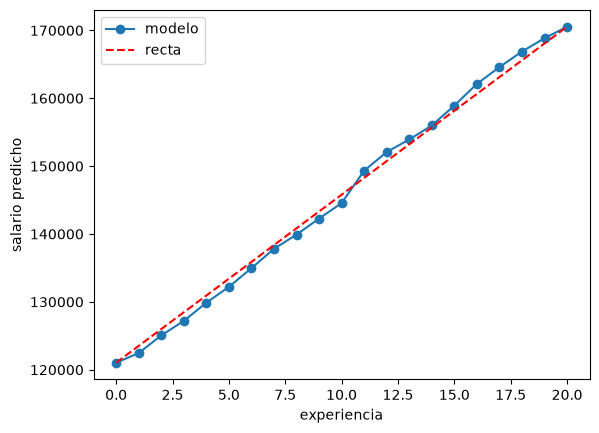

In [ ]:
perfiles = X_test.copy()   # todos los perfiles del test, no una muestra
exp = []
for e in range(0, 21): #tomamos todos los perfiles del test y solo cambiamos la experiencia (0 a 20), dejando lo demas igual
    perfiles["experience_years"] = e   #le cambiamos solo la experiencia
    exp.append(modelo.predict(perfiles).mean()) #salario predico para esa experiencia

plt.plot(range(0, 21), exp, marker="o", label="modelo") #curva real del modelo
plt.plot([0, 20], [exp[0], exp[-1]], "--", color="red", label="recta") #recta lineal
plt.xlabel("experiencia")
plt.ylabel("salario predicho")
plt.legend()
plt.show()

Podemos notar que el modelo nos muestra que el efecto de la experiencia sobre el salario es practicamente lineal, las predicciones del modelo siguen muy de cerca a la recta de referencia en todo el rango, esto significa que cada año adicional de experiencia aporta aproximadamente lo mismo al salario. Se observan desviaciones muy pequeñas respecto a la recta, pero son minimas y no muestran un patron claro, por lo que podemos concluir que el modelo trata la experiencia como una variable de efecto practicamente lineal sobre el salario

# Probar el modelo
Ahora crearemos la funcion para predecir nuestro salario con el modelo creado, indicando las variables de años de experiencia, cargo, pais, tamaño de empresa y educacion

In [ ]:
def predecir_salario(experiencia, cargo, pais, tamaño, educacion): #funcion para probar el modelo creado
    fila = pd.DataFrame([{ #armamos una fila con los datos de entrada, las variables seleccionadas
        "experience_years": experiencia,
        "job_title": cargo,
        "location": pais,
        "company_size": tamaño,
        "education_level": educacion,
    }])
    fila = pd.get_dummies(fila, columns=VAR_CAT) #usamos el mismo one-hot que en el entrenamiento
    fila = fila.reindex(columns=X.columns, fill_value=0) #reindex deja las mismas columnas que x, si faltan rellena con 0
    return modelo.predict(fila)[0] #nos indica el salario estimao anual en usd

print(predecir_salario(10, "Data Analyst", "USA", "Large", "Master")) #pruebas
print(predecir_salario(10, "Data Analyst", "India", "Large", "Master"))

156908.15083333335
90997.5275


Ahora utilizamos la funcion y agregamos los inputs para que el usuario pueda probarlo con sus variables, ademas imprimimos las posibles respuestas que debe dar el usuario

In [ ]:
print("Cargos disponibles:", sorted(data["job_title"].unique())) #mostramos todas las opciones que pide el modelo por variable
print("Paises disponibles:", sorted(data["location"].unique()))
print("Tamaños de empresa:", sorted(data["company_size"].unique()))
print("Niveles de educacion:", sorted(data["education_level"].unique()))
print("Experiencia: un numero entero entre 0 y 20")
print()

exp = int(input("experiencia (0-20): ")) #pedimos las entradas al usuario para utilizar el modelo
cargo = input("cargo: ")
pais = input("pais: ")
tamaño = input("tamaño empresa: ")
edu = input("educacion: ")
print("salario estimado:", round(predecir_salario(exp, cargo, pais, tamaño, edu))) #usamos la funcion anterior y nos muestra el salario estimado

Cargos disponibles: ['AI Engineer', 'Backend Developer', 'Business Analyst', 'Cloud Engineer', 'Cybersecurity Analyst', 'Data Analyst', 'Data Scientist', 'DevOps Engineer', 'Frontend Developer', 'Machine Learning Engineer', 'Product Manager', 'Software Engineer']
Paises disponibles: ['Australia', 'Canada', 'Germany', 'India', 'Netherlands', 'Remote', 'Singapore', 'Sweden', 'UK', 'USA']
Tamaños de empresa: ['Enterprise', 'Large', 'Medium', 'Small', 'Startup']
Niveles de educacion: ['Bachelor', 'Diploma', 'High School', 'Master', 'PhD']
Experiencia: un numero entero entre 0 y 20

salario estimado: 92127


# Conclusiones generales
Dentro de proyecto pudimos crear un modelo predictor utilizando random forest, evaluado con k-fold y mse, indicando variables significativas como son los años de experiencia, cargo, pais, tamaño de la empresa y nivel de educacion. En la creacion del modelo se generaron instancias de analisis como la seleccion de variable, analizando las mas importantes y significativas para el efecto predictor del salario, ademas de probar los parametros del modelo random forest, donde terminamos eligiendo 200 arboles y con una profundidad maxima de 20, intentando optimizar la eficiencia computacional y el riesgo de overfitting.

Analizamos algunas hipotesis, donde verificamos que la varible que mayor efecto tiene sobre el salario es el pais en donde trabajamos o de donde nos contratan (location) y que seguido de esto son los años de experiencia, tambien notamos entre las variables importantes para el efecto del salario, la educacion era la que menos efecto tenia.

En cuanto a la linealidad de la experiencia, fallamos en nuestra hipotesis y pudimos ver, gracias al grafico que el efecto de la experiencia sobre los salarios es practicamente lineal, aportando practicamente la misma cantidad de dinero, por año de experiencia, sin importar el cuando.